# 4-Site-FMO, **markovsche** Dynamik auf echter IBM-Hardware — 3 Qubits, ein durchgängiger Schaltkreis

Dieses Notebook rechnet dieselbe Physik wie
`non_markov/hardware_4_site_FMO_with_compression/main_hardware.ipynb`, aber mit der
**Born-Markov-Sekular-Näherung** statt der exakten HEOM-Hierarchie — gleiche Parameter
($\lambda=35$, $\gamma=50$ cm⁻¹, $T=300$ K), gleicher Hamiltonian, gleiche
Hardware-Maschinerie. Was sich in den Kurven unterscheidet, ist damit **die Näherung
und nicht das Verfahren**.

## Die Aufteilung

| Datei | Inhalt |
|---|---|
| `markov_grid.py` | die Logik des durchgängigen markovschen Gitters — Generator, Eichung, Krylov, Dilatation. Kennt keinen Quantenrechner. |
| `hardware.py` | alles, was mit der Maschine zu tun hat — Schaltkreise, Kosten, Absenden, Auswerten |
| dieses Notebook | Parameter setzen, in Aer gegenprüfen, losschicken, plotten |

## Warum **nicht** über die Kraus-Operatoren

Der naheliegende markovsche Weg steht in `Markov/single_grid_markov.ipynb`: Choi →
Kraus-Operatoren $M_k(\Delta t)$ → Stinespring-Dilatation, und dann

$$\rho_n=\operatorname{Tr}_E\!\big[U(|0\rangle\langle0|_E\otimes\rho_{n-1})U^\dagger\big]$$

mit in jedem Schritt demselben $U$. Mathematisch ist das die schönere Route: die
Abbildung ist CPTP, also $p_{\rm success}=1$, **keine** Nachselektion, **kein**
$\lambda_t$, und die Populationen wären direkt die Zählraten der beiden Systemqubits.

Sie ist auf heutiger Hardware nur nicht lauffähig. Gemessen (lineare Kette,
Heron-Basisgatter, als Isometrie synthetisiert — das ist bereits die billigere
Variante gegenüber der vollen Unitären):

| behaltene Kraus-Op. | $n_{\rm env}$ | Qubits | **CZ je Schritt** | algorithm. Fehler |
|---|---|---|---|---|
| 16 (exakt) | 4 | 6 | **591** | 0 |
| 8 | 3 | 5 | 254 | 5e-3 … 5e-2 |
| 4 | 2 | 4 | 109 | 9e-2 … 2e-1 |
| 2 | 1 | 3 | 31 | 2.3e-1 |

Der Grund steht im Choi-Spektrum. Bei $\lambda=35$ und $\Delta t=20$ fs sind die
Eigenwerte

$$1.724 \;/\; 0.815 \;/\; 0.578 \;/\; 0.415 \;/\; 0.155 \;/\; 0.134 \;/\; \dots$$

— sie fallen **nicht** ab, der Kanal hat vollen Kraus-Rang $d^2=16$. Abschneiden kostet
sofort zweistellige Prozente, und 591 CZ je Schritt geben bei 2,66e-3 Fehler je CZ
schon bei $t=1$ eine Treue von 0,17. Bei schwacher Kopplung ($\lambda=3$) sähe das
anders aus — dort trägt der erste Eigenwert 3,83 von 4 — aber danach ist hier nicht
gefragt.

## Der Weg, der läuft

Stattdessen wird der **Vektor** $\mathrm{vec}(\rho)$ propagiert, genau wie im
nicht-markovschen Ordner: Liouvillian → Kontraktionseichung → Krylov-Kompression auf
$m$ Dimensionen → SVD-Dilatation. Ergebnis: **3 Qubits, 13 CZ je Schritt.** Bezahlt
wird das mit Nachselektion ($p_t\approx0{,}75$) und der $\sqrt{q}$-Ablesung.

| | Stinespring (Kraus) | **hier** (Superoperator + Krylov) |
|---|---|---|
| propagiert wird | $\rho$ als Matrix | $\mathrm{vec}(\rho)$ als Vektor |
| Register | 2 System + 4 Umgebung | 2 Krylov + 1 Ancilla |
| CZ je Schritt | 591 | **13** |
| $p_{\rm success}$ | 1 | 0,75 |
| Ablesung | direkt aus den Zählraten | $\rho_{jj}=\lVert r\rVert\lambda_t\sqrt{q}$ |
| durchgängig? | ja | ja |

Beides sind durchgängige Gitter — das Systemregister wird in **keiner** der beiden
Varianten gemessen oder neu präpariert.


In [33]:
import os, sys, time
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
import hardware as hw
import markov_grid as mg

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.titlesize': 10, 'legend.fontsize': 8})
PIC = 'pictures'; os.makedirs(PIC, exist_ok=True)

# --- Parameter des Laufs -------------------------------------------------
N_SITES  = 4                       # 2, 3 oder 4 -- Block des FMO-Hamiltonians
LAM      = 35.0                    # Reorganisationsenergie [cm^-1]
GAMMA    = 50.0                    # Badabschneidefrequenz [cm^-1] -- wie im non-Markov-Lauf
T_K      = 300.0                   # Temperatur [K]
DT_FS    = 20.0                    # Zeitschritt
TIMES    = list(range(1, 11))      # t = 1..10  ->  20..200 fs
M_KRYLOV = 4                       # 4 -> 3 Qubits, 8 -> 4 Qubits
DELTA    = 10.0                    # Optimum des GESAMTfehlers -- siehe 1a
METHOD   = 'svd'                   # 'svd' (empfohlen) oder 'sznagy'
DEFER    = True                    # aufgeschobene Messung -- siehe 1c
FLOOR    = False                   # Nullkanal je Zeit: misst den Rauschboden direkt
PAIRS    = [(0, 1)]                # Kohaerenzen; je Paar +2 Schaltkreise/Zeit
SHOTS    = 8192
BACKEND  = 'ibm_kingston'          # von den zugaenglichen QPUs die beste

MODEL, RHO0 = mg.make_model(N_SITES, lam=LAM, gamma=GAMMA, T_K=T_K)
grid = hw.build_hardware_grid(n_sites=N_SITES, m=M_KRYLOV, dt_fs=DT_FS,
                              delta=DELTA, model=MODEL, rho0=RHO0)
N    = grid['d']
cols = plt.cm.tab10(np.arange(N))

  4 Sites, lam = 35.0, gamma = 50.0 cm^-1, T = 300 K, dt = 20 fs
  A: 16 x 16 (52 Sprungoperatoren)
  Eichung delta = 10.0 cm^-1: cond(W) = 4.63e+01, ||P|| = 1.00384 -> ||P~|| = 1.003171 (Schranke 1.038392)
  Krylov m = 4 -> gepolstert 4, 3 Qubits, ||H_m|| = 0.997286, s = 0.997286, s^25 = 0.9343
  Singulaerwerte von H_m/s: 0.386026 bis 1.000000
  Aufbau 0.02 s (einmalig, unabhaengig von der Zahl der Zeitschritte)


## 1a  Die Parameterwahl: $\delta$, $m$ und $t_{\max}$

Der einzige sinnvolle Maßstab ist der **Gesamtfehler**

$$\varepsilon_{\rm ges}=\sqrt{\varepsilon_{\rm Algorithmus}^2+\varepsilon_{\rm Statistik}^2}$$

Der Algorithmusfehler kommt aus der Krylov-Abschneidung bei $m$, der statistische aus
$\delta\rho=\lVert r\rVert\lambda_t/(2\sqrt{N_{\rm acc}})$ mit
$\lambda_t=\lVert y_0\rVert s^t\sqrt{p_t}$. Alles unten gemessen bei $t=10$, 2048 Shots.

### $\delta=10$, nicht 2 und nicht 30

| $\delta$ | $p_t$ | Verstärkung $A$ | Algorithmus | Statistik | **Gesamt** | CZ |
|---|---|---|---|---|---|---|
| 2 | 0,970 | 4,40 | 6,8e-2 | 0,0494 | 0,0842 | 170 |
| **10** | **0,868** | **1,90** | **5,2e-2** | **0,0226** | **0,0566** | 170 |
| 30 | 0,747 | 1,15 | 6,2e-2 | 0,0147 | 0,0637 | 170 |
| 60 | 0,661 | 0,88 | 7,1e-2 | 0,0120 | 0,0717 | 170 |
| 120 | 0,576 | 0,72 | 7,8e-2 | 0,0104 | 0,0785 | 170 |

**Die Gatterzahl ist von $\delta$ unabhängig** — 170 CZ bei jedem Wert. $\delta$ kostet
also nichts in der Tiefe, nur Nachselektion gegen Ablesegenauigkeit.

> **Korrigiert.** Eine frühere Fassung dieser Tabelle nannte $\delta=30$ als Optimum.
> Sie war mit einem fehlerhaften Generator gerechnet: in `calc_L_list` trugen die
> energieanhebenden Sprungoperatoren die Emissions- statt der Absorptionsrate, sodass
> der Generator exakt in die **Anti-Boltzmann-Verteilung** relaxierte. Nach der
> Korrektur liegt das Optimum bei $\delta=10$ — demselben Wert wie im
> nicht-markovschen Ordner. Der Algorithmusfehler hat dort ein Minimum, während die
> Statistik erst danach nennenswert gewinnt.

Das ist derselbe Befund wie im nicht-markovschen Ordner, aber bei anderem Optimum
(dort $\delta=10$): der Lindblad-Liouvillian ist mit $\lVert P\rVert_2=1{,}0043$ von
Haus aus fast kontraktiv, die Eichung muss also viel weniger reparieren, und man kann
sie stärker zugunsten der Ablesung drehen.

### $m=4$, obwohl $m=8$ algorithmisch exakt wäre

| $m$ | Qubits | CZ bei $t=10$ | Gattertreue | Algorithmus $t=10$ | Statistik | **Gesamt** |
|---|---|---|---|---|---|---|
| **4** | **3** | **170** | **0,636** | 6,2e-2 | 0,015 | **0,064** |
| 8 | 4 | 814 | 0,114 | 1,3e-4 | 0,017 | 0,017 |

$m=8$ macht den Algorithmusfehler praktisch verschwinden — und ruiniert dabei die
Hardware: 814 statt 170 CZ, Gattertreue 0,11 statt 0,64. Das Ergebnis wäre zu 89 %
Rauschen. Der Grund ist $m_p$: bei $m=4$ ist das gepolsterte Register 2 Qubits breit
und $U,V^\dagger$ kosten 3 CZ, bei $m=8$ sind es 3 Qubits und rund 20 CZ — **je Schritt**.

Weil $D=d^2=16$ ist, wäre $m=16$ übrigens schon die **unkomprimierte** Rechnung. Der
markovsche Raum ist von Haus aus klein; die Kompression bringt hier Faktor 4 in der
Dimension, nicht Faktor 180 wie bei den 720 HEOM-Dimensionen.

### Wo $m=4$ exakt ist und wo nicht

Der Krylov-Raum $\mathcal{K}_m(\tilde P,\tilde x_0)$ enthält die ersten $m$ Schritte
**exakt** und extrapoliert darüber hinaus:

| $t$ | 1 | 2 | 3 | 4 | 5 | 6 | 8 | 10 |
|---|---|---|---|---|---|---|---|---|
| Algorithmusfehler | 1,2e-8 | 1,5e-8 | 5,9e-9 | 3,7e-3 | 1,0e-2 | 1,8e-2 | 3,1e-2 | 4,2e-2 |
| $p_t$ (ideal) | 0,836 | 0,785 | 0,765 | 0,757 | 0,754 | 0,752 | 0,752 | 0,751 |

Bis $t=3$ ist es Maschinengenauigkeit, ab $t=4$ wächst der Fehler linear. Bei $t=10$
liegt er mit 4,2e-2 **über** dem statistischen (0,016) — der Lauf ist dort also
algorithmusbegrenzt, nicht shotbegrenzt. Mehr Shots bringen ab $t\approx6$ nichts mehr.


### 1b  SVD statt Sz.-Nagy

Die volle Sz.-Nagy-Dilatation macht aus $M$ ein **beliebiges** 3-Qubit-Unitary.
Seneviratne et al. zerlegen stattdessen

$$M=U\Sigma V^\dagger,\qquad U_\Sigma=\begin{pmatrix}\Sigma_+&0\\0&\Sigma_-\end{pmatrix},\qquad \Sigma_\pm=\sigma_j\pm i\sqrt{1-\sigma_j^2}$$

und dilatieren **nur die Diagonale**. $U$ und $V^\dagger$ wirken auf die 2
Krylov-Qubits — ein beliebiges 2-Qubit-Unitary braucht 3 CNOTs — und eine Diagonale auf
3 Qubits kostet $\sim2^3$ statt $4^3$. $\sigma_j\le1$ ist garantiert, weil
$s\ge\lVert H_m\rVert$.

**Die Durchgängigkeit ändert sich dadurch nicht.** Beides sind Dilatationen desselben
$M$ — der $|0\rangle$-Ancillazweig trägt in beiden Fällen $M$, sie unterscheiden sich
nur im verworfenen $|1\rangle$-Zweig. Klassisch wird die SVD **einmal** berechnet.

### 1c  Aufgeschobene Messung

Statt eine Ancilla zu messen und zurückzusetzen, bekommt **jeder Zeitschritt ein eigenes
frisches Ancilla-Qubit**, und alle Messungen stehen am Ende. Nach dem Prinzip der
aufgeschobenen Messung ist das exakt äquivalent, solange kein Gatter von einem
Messergebnis abhängt — und das tut hier keines.

Der Grund steht ausführlich im nicht-markovschen Notebook (Abschnitt 1c): der erste
Hardware-Lauf dort ließ sich mit den publizierten Fehlerraten nicht erklären, erst ein
effektiver 2Q-Fehler von 5 % traf die Daten. Eine Mid-Circuit-Messung dauert
Mikrosekunden, und währenddessen dephasieren die benachbarten Systemqubits; der Reset
ist auf IBM-Hardware selbst wieder eine Messung mit bedingtem X. Der Schaltkreis hier
hat dieselbe Form, also gilt dieselbe Diagnose.

Kosten: **null zusätzliche Zweiqubit-Gatter**, dafür $t$ statt 1 Ancilla — bei $t=10$
sind das 12 Qubits statt 3. `kingston` hat 156.

`DEFER = False` reproduziert die Variante mit Reset.

## 1  Die Schaltkreise

Je Auslesezeit **und je Ablesezeile** ein Schaltkreis — die Messung zerstört den
Zustand. Im komprimierten Krylov-Raum sind die Ablesezeilen $r_{jj}$ **dicht** (anders
als ohne Kompression, wo sie Basisvektoren sind), deshalb braucht jede ihre eigene
Basisdrehung $B^\dagger$ mit $B|0\rangle=\chi_j$, $\chi_j=\overline{r_j}/\lVert r_j\rVert$.
Gemessen wird dann

$$q_j=P\big(|0\dots0\rangle\,\big|\,\text{Ancilla-Protokoll}=0\dots0\big),\qquad
\rho_{jj}=\lVert r_j\rVert\,\lambda_t\sqrt{q_j},\qquad
\lambda_t=\lVert y_0\rVert\,s^t\sqrt{p_t}.$$

Kohärenzen über die ++/RR-Drehung,
$\rho_{++}=\tfrac12(\rho_{aa}+\rho_{bb})+\mathrm{Re}\,\rho_{ab}$.

Nur legale Befehle: `unitary`, `measure`, `reset`. Kein `save_statevector` — das gibt es
auf Hardware nicht.


  60 Schaltkreise = 10 Zeiten x (4 Populationen + 2 x 1 Paare)


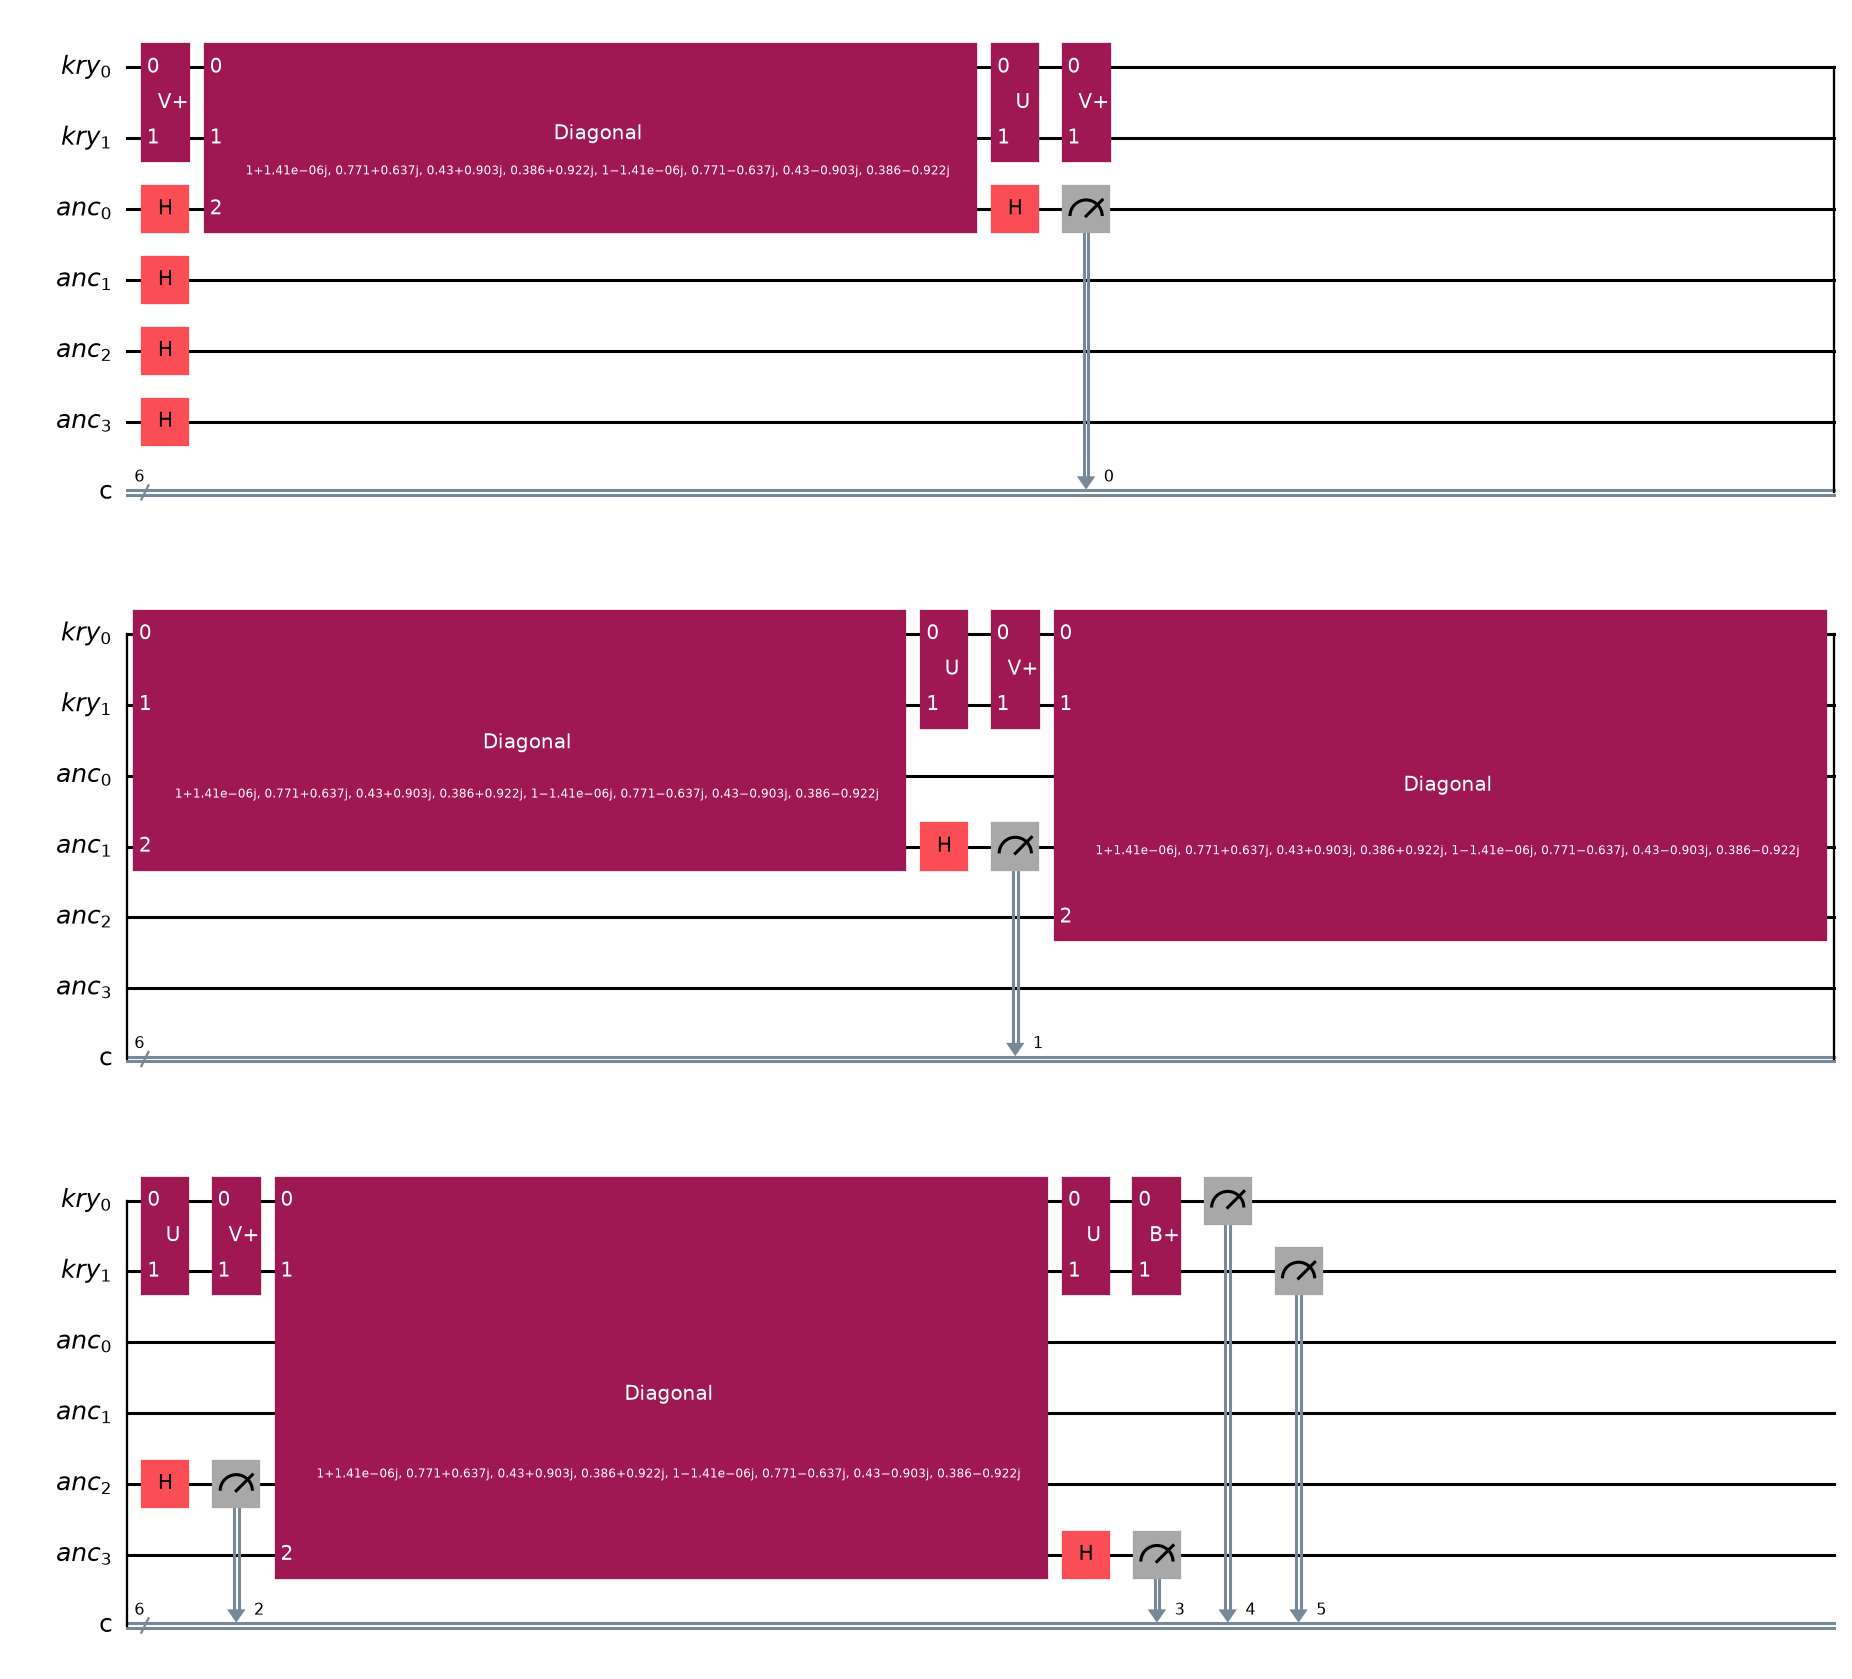

In [34]:
jobs = hw.hardware_circuits(grid, TIMES, PAIRS, method=METHOD, defer=DEFER,
                            floor=FLOOR)
print(f"  {len(jobs)} Schaltkreise = {len(TIMES)} Zeiten x "
      f"({N} Populationen + 2 x {len(PAIRS)} Paare"
      + (" + 1 Nullkanal" if FLOOR else "") + ")")

n_rows = N + 2 * len(PAIRS) + (1 if FLOOR else 0)
jobs[3 * n_rows]['circuit'].draw('mpl', fold=24)   # t = 4, Kanal ('pop',0,0)

Im Bild: jeder Block ist ein Zeitschritt — `V+` auf den beiden Krylov-Qubits, `H` auf
der Ancilla dieses Schritts, das `Diagonal` über alle drei, `H` zurück, `U`. Am Ende
steht `B+`, die Basisdrehung der Ablesezeile, und dann die Messungen.

Die `Diagonal`-Matrix geht **nicht** über alle Qubits, sondern immer nur über drei — das
lässt sich an den Zahlen am linken Rand der Anzeige ablesen. Jedes `H` ganz am Anfang
gehört zu dem `H`, das am anderen Ende seines `Diagonal` steht; es wird nur grafisch
vorgezogen, weil vor ihm nichts steht.

## 2  Was der Lauf kostet — **vor** dem Absenden

Bei knappem QPU-Budget lohnt es sich, das vorher zu wissen. Zwei Annahmen gehen ein:

* **Topologie.** IBMs Heavy-Hex-Gitter hat **keine Dreiecke**. Die fehlenden
  Verbindungen kosten SWAPs, und bei aufgeschobener Messung müssen alle $t$ Ancillas
  dasselbe Krylov-Paar berühren. Die Zelle rechnet mit einer linearen Kette;
  `backend=...` gibt stattdessen die echte ISA.
* **`rep_delay`.** Die Wartezeit zwischen den Shots. Sie macht hier **98 %** der
  QPU-Zeit aus. Der Wert 311 µs ist an einem echten Lauf kalibriert (Job
  `da833pe0ukec7383ughg`, 42 s tatsächlich).


In [35]:
kosten = hw.report_cost(grid, jobs, shots=SHOTS)

budget = 10 * 60          # 10 Minuten pro Monat
print("")
print(f"  Dein Budget: {budget} s pro Monat -> etwa "
      f"{int(budget / kosten['qpu_seconds'])} Laeufe dieser Groesse.")
print("")
print("  Stellschrauben, falls es knapp wird:")
print(f"    Shots halbieren       -> halbe Zeit, Fehlerbalken x 1.41")
print(f"    ein Zeitpunkt weniger -> {kosten['qpu_seconds'] / len(TIMES):.0f} s gespart")
print(f"    Kohaerenzen weglassen -> "
      f"{2 * len(PAIRS) / (N + 2 * len(PAIRS)) * 100:.0f} % gespart")

  60 Schaltkreise, 3 Gitter- + bis 9 Ancilla-Qubits = 12, 8192 Shots je Schaltkreis, Dilatation 'svd'
  Messung: aufgeschoben -- 0 Resets, alles am Ende
  Zweiqubit-Gatter: 13 bis 171 (Median 77), Tiefe bis 436

    t  2Q-Gatter  Tiefe  Treue (Gatter)
    1         13     53           0.965
    2         24     96           0.937
    3         38    139           0.903
    4         52    182           0.870
    5         69    225           0.831
    6         85    264           0.796
    7        105    307           0.755
    8        124    346           0.718
    9        148    393           0.673
   10        170    432           0.635

  geschaetzte QPU-Zeit : 156.7 s  (2.61 min)
    davon rep_delay    : 152.9 s (98%)
  Annahmen: 2.66e-03 Fehler je 2Q-Gatter, 68 ns je 2Q, 311 us rep_delay, Topologie: lineare Kette

  Dein Budget: 600 s pro Monat -> etwa 3 Laeufe dieser Groesse.

  Stellschrauben, falls es knapp wird:
    Shots halbieren       -> halbe Zeit, Fehlerbalken x 1.41

## 3  Kostenlos gegenprüfen — **genau die Kreise, die rausgehen**

`verify_in_aer` simuliert `j['transpiled']`, also das Ergebnis der Zelle oben — nicht
die abstrakte Vorstufe. Was hier schon danebenliegt, wird auf der Maschine nicht besser.

Ein Vorbehalt: oben wurde gegen eine **lineare Kette** transpiliert, die echte Maschine
hat aber Heavy-Hex. Wer wirklich die ISA-Kreise simulieren will, setzt `ISA_ECHT = True`
— dann wird einmal das Backend geholt und gegen dessen echten Kopplungsgraphen
transpiliert. Das kostet **keine** QPU-Zeit (Transpilation läuft lokal), braucht aber
ein hinterlegtes Konto.


In [36]:
ISA_ECHT = False        # True: gegen die echte kingston-ISA transpilieren

if ISA_ECHT:
    from qiskit_ibm_runtime import QiskitRuntimeService
    backend = QiskitRuntimeService().backend(BACKEND)
    print(f"  transpiliere gegen die echte ISA von {backend.name} ...")
    kosten = hw.report_cost(grid, jobs, shots=SHOTS, backend=backend)

rho_aer, err_aer, info_aer = hw.verify_in_aer(grid, jobs, shots=SHOTS, pairs=PAIRS)


  Aer gegen qutip mesolve (Lindblad):
    t =   20 fs | p_succ 0.923 | Spur 1.0042 | max|dPop| ueber p_t 0.0129 | spurnormiert 0.0103
    t =   40 fs | p_succ 0.893 | Spur 0.9908 | max|dPop| ueber p_t 0.0094 | spurnormiert 0.0054
    t =   60 fs | p_succ 0.874 | Spur 0.9689 | max|dPop| ueber p_t 0.0144 | spurnormiert 0.0060
    t =   80 fs | p_succ 0.872 | Spur 1.0054 | max|dPop| ueber p_t 0.0071 | spurnormiert 0.0057
    t =  100 fs | p_succ 0.871 | Spur 1.0215 | max|dPop| ueber p_t 0.0148 | spurnormiert 0.0085
    t =  120 fs | p_succ 0.863 | Spur 0.9940 | max|dPop| ueber p_t 0.0271 | spurnormiert 0.0290
    t =  140 fs | p_succ 0.872 | Spur 0.9689 | max|dPop| ueber p_t 0.0430 | spurnormiert 0.0427
    t =  160 fs | p_succ 0.871 | Spur 1.0063 | max|dPop| ueber p_t 0.0457 | spurnormiert 0.0436
    t =  180 fs | p_succ 0.866 | Spur 0.9711 | max|dPop| ueber p_t 0.0429 | spurnormiert 0.0530
    t =  200 fs | p_succ 0.866 | Spur 0.9903 | max|dPop| ueber p_t 0.0556 | spurnormiert 0.0590


### 3b  Der algorithmische Fehler allein

Der Aer-Lauf mischt zwei Dinge: die Krylov-Abschneidung und das Shot-Rauschen. Diese
Zelle trennt sie — sie rechnet rein klassisch und braucht keinen Simulator.


In [37]:
t_ex   = np.arange(max(TIMES) + 1) * grid['dt_fs']
ref_rho = mg.qutip_reference_rho(t_ex, rho0=grid['rho0'], **grid['model'])
kry     = mg.reference_trajectory(grid, max(TIMES))            # das, was das Gitter tut
exakt   = mg.reference_trajectory(grid, max(TIMES), exact=True) # ohne Kompression
p_ideal = mg.post_selection_curve(grid, max(TIMES))

print(f"  {'t':>3s} {'t/fs':>6s} {'Krylov m=%d' % grid['m']:>12s} "
      f"{'ohne Kompr.':>12s} {'p_t ideal':>10s}")
for t in TIMES:
    e_k = np.abs(np.real(np.diag(kry[t]))   - np.real(np.diag(ref_rho[t]))).max()
    e_x = np.abs(np.real(np.diag(exakt[t])) - np.real(np.diag(ref_rho[t]))).max()
    print(f"  {t:3d} {t*grid['dt_fs']:6.0f} {e_k:12.2e} {e_x:12.2e} {p_ideal[t]:10.4f}")

print("\n  'ohne Kompr.' ist der geeichte Propagator P~ ohne Krylov-Abschneidung.")
print("  Dass er bei 1e-9 liegt, sagt: Eichung und Ablesematrix R sind exakt --")
print("  der ganze sichtbare Fehler kommt allein aus der Kompression auf m =", grid['m'])

    t   t/fs   Krylov m=4  ohne Kompr.  p_t ideal
    1     20     1.25e-08     1.25e-08     0.9186
    2     40     1.43e-08     1.43e-08     0.8913
    3     60     8.03e-09     8.03e-09     0.8790
    4     80     4.56e-03     1.66e-09     0.8729
    5    100     1.28e-02     7.66e-10     0.8700
    6    120     2.24e-02     1.28e-09     0.8688
    7    140     3.16e-02     1.06e-09     0.8683
    8    160     3.96e-02     1.11e-09     0.8681
    9    180     4.63e-02     1.36e-09     0.8680
   10    200     5.19e-02     4.61e-10     0.8679

  'ohne Kompr.' ist der geeichte Propagator P~ ohne Krylov-Abschneidung.
  Dass er bei 1e-9 liegt, sagt: Eichung und Ablesematrix R sind exakt --
  der ganze sichtbare Fehler kommt allein aus der Kompression auf m = 4


### 3c  Der Krylov-Fehler je Site — woher das Auseinanderlaufen kommt

Zelle 3b fasst den Fehler als **Maximum über alle Sites** zusammen. Das verdeckt seine
eigentliche Struktur: die Abschneidung verrauscht die Populationen nicht gleichmäßig,
sondern **verschiebt sie gerichtet zwischen den Sites**.

`mg.krylov_fehler_je_site` behält deshalb die Auflösung nach Site *und* das Vorzeichen.
Verglichen wird spurnormiert, also so, wie der Plot in Abschnitt 4 abliest.

Das mittlere Panel zeigt den Sprung über sieben Größenordnungen bei $t=m=4$: solange
$t \le m-1$ gilt, enthält $\mathcal K_m$ den Vektor $P^t y_0$ **exakt** (Fehler
$\sim10^{-9}$), danach wird extrapoliert. Die gestrichelte Linie ist der geeichte
Propagator **ohne** Kompression — dass sie bei $10^{-9}$ bleibt, belegt, dass Eichung
und Ablesematrix $R$ sauber sind und der ganze sichtbare Fehler allein aus der
Kompression stammt.

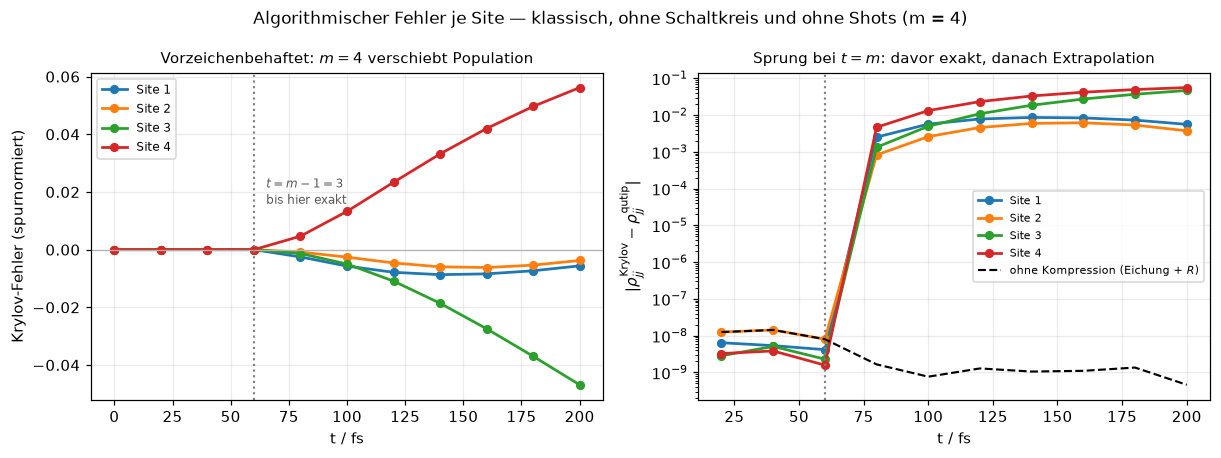

    t   t/fs    Site 1    Site 2    Site 3    Site 4
    1     20   +0.0000   -0.0000   +0.0000   +0.0000
    2     40   +0.0000   -0.0000   +0.0000   +0.0000
    3     60   +0.0000   -0.0000   +0.0000   +0.0000
    4     80   -0.0025   -0.0008   -0.0013   +0.0047
    5    100   -0.0057   -0.0026   -0.0050   +0.0133
    6    120   -0.0079   -0.0046   -0.0109   +0.0234
    7    140   -0.0087   -0.0060   -0.0186   +0.0332
    8    160   -0.0084   -0.0062   -0.0274   +0.0420
    9    180   -0.0073   -0.0054   -0.0370   +0.0497
   10    200   -0.0056   -0.0037   -0.0469   +0.0562

  ohne Kompression bei t=10: [-8.5e-11  4.6e-10 -3.3e-10 -4.7e-11]
  -> Eichung und Ablesematrix R sind exakt; der sichtbare Fehler
     kommt vollstaendig aus der Kompression auf m = 4.


In [38]:
kf = mg.krylov_fehler_je_site(grid, max(TIMES))
t_kf, F, Fx = kf['t_fs'], kf['fehler'], kf['fehler_exakt']

fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.2))

for j in range(N):                                  # (a) vorzeichenbehaftet
    ax[0].plot(t_kf, F[:, j], 'o-', color=cols[j], lw=1.8, ms=5,
               label=f'Site {j+1}')
ax[0].axhline(0, color='0.7', lw=.8)
ax[0].axvline((grid['m'] - 1) * grid['dt_fs'], color='0.5', ls=':', lw=1.4)
ax[0].annotate(rf'$t=m-1={grid["m"]-1}$' + '\nbis hier exakt',
               xy=((grid['m'] - 1) * grid['dt_fs'], 0), xytext=(8, 30),
               textcoords='offset points', fontsize=8, color='0.35')
ax[0].set_ylabel('Krylov-Fehler (spurnormiert)')
ax[0].set_title(rf'Vorzeichenbehaftet: $m={grid["m"]}$ verschiebt Population')
ax[0].legend(fontsize=8)

for j in range(N):                                  # (b) Betrag, logarithmisch
    ax[1].semilogy(t_kf[1:], np.abs(F[1:, j]), 'o-', color=cols[j], lw=1.8, ms=5,
                   label=f'Site {j+1}')
ax[1].semilogy(t_kf[1:], np.abs(Fx[1:, :]).max(axis=1), 'k--', lw=1.4,
               label='ohne Kompression (Eichung + $R$)')
ax[1].axvline((grid['m'] - 1) * grid['dt_fs'], color='0.5', ls=':', lw=1.4)
ax[1].set_ylabel(r'$|\rho_{jj}^{\rm Krylov} - \rho_{jj}^{\rm qutip}|$')
ax[1].set_title('Sprung bei $t=m$: davor exakt, danach Extrapolation')
ax[1].legend(fontsize=7.5)

for a in ax:
    a.set_xlabel('t / fs'); a.grid(alpha=.25)
fig.suptitle(f'Algorithmischer Fehler je Site — klassisch, ohne Schaltkreis und '
             f'ohne Shots (m = {grid["m"]})', fontsize=11)
fig.tight_layout()
fig.savefig(f'{PIC}/krylov_fehler_je_site.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  {'t':>3s} {'t/fs':>6s} " + ' '.join(f'{"Site "+str(j+1):>9s}'
                                              for j in range(N)))
for t in TIMES:
    print(f"  {t:3d} {t_kf[t]:6.0f} " + ' '.join(f'{F[t, j]:+9.4f}'
                                                 for j in range(N)))
print(f"\n  ohne Kompression bei t={max(TIMES)}: "
      f"{np.array2string(Fx[max(TIMES)], precision=1)}")
print(f"  -> Eichung und Ablesematrix R sind exakt; der sichtbare Fehler")
print(f"     kommt vollstaendig aus der Kompression auf m = {grid['m']}.")

## 4  Auf die echte Maschine

### Einmalig einrichten

```bash
pip install qiskit-ibm-runtime
```

```python
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(token="DEIN_TOKEN", overwrite=True)
```

Den Token bekommst du nach der Registrierung auf der IBM Quantum Platform. Den genauen
`channel`-Namen und die aktuellen Limits des kostenlosen Plans nimm bitte von der
Plattform selbst — die haben sich mehrfach geändert.

### Was beim Absenden passiert

Du lädst **keine Datei** hoch. `run_on_backend` transpiliert lokal gegen die echte ISA
der Maschine (Kopplungsgraph, Basisgatter, Kalibrierung) und schickt nur die
serialisierten Schaltkreise. Zurück kommen Zählraten. Deshalb muss **je Backend neu
transpiliert** werden — das ist der eine Parameter `backend_name`.

### Fehlerunterdrückung

`run_on_backend` schaltet zwei Dinge zu, beide kostenlos in QPU-Zeit:

* **Pauli-Twirling** (Gatter und Messung) wandelt **kohärente** Fehler in stochastische
  um. Genau der richtige Hebel hier: der Schaltkreis wiederholt *dasselbe* Gatter
  $n$-mal, ein systematischer Rotationsfehler addiert sich also kohärent auf —
  Fehler $\propto n$ statt $\propto\sqrt n$.
* **Dynamical Decoupling (XY4, ALAP)** unterdrückt Dephasierung im Leerlauf. Bei
  aufgeschobener Messung schützt es vor allem die wartenden Ancillas, die bis zu ihrem
  Schritt in $|+\rangle$ liegen.

Abschalten mit `run_on_backend(..., twirling=False, dd=False)`.


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Der Token liegt nach dem ersten Mal in ~/.qiskit/qiskit-ibm.json und muss hier
# NICHT stehen -- so kann er auch nicht versehentlich mit dem Notebook auf
# GitHub landen.  Nur fuer ein NEUES Konto: TOKEN einmalig fuellen, ausfuehren,
# wieder leeren.
TOKEN = ""
if TOKEN:
    QiskitRuntimeService.save_account(token=TOKEN, overwrite=True)
    print("  neues Konto hinterlegt")
else:
    try:
        QiskitRuntimeService()          # nutzt das gespeicherte Konto
        print("  gespeichertes Konto gefunden -- kein Token noetig")
    except Exception as e:
        print(f"  KEIN Konto: {e}\n  -> TOKEN oben einmalig eintragen.")

COUNTS_FILE = f'ibm_kingston_markov_{int(max(TIMES)*DT_FS)}fs_m{M_KRYLOV}.npy'

# ACHTUNG: verbraucht QPU-Zeit.  Erst ausfuehren, wenn Abschnitt 2 und 3 passen.
LOSSCHICKEN = False          # auf True setzen, wenn du bereit bist

counts = None
if LOSSCHICKEN:
    if os.path.exists(COUNTS_FILE):      # alten Lauf nicht verlieren
        sich = COUNTS_FILE.replace('.npy',
                                   f"_{time.strftime('%Y%m%d_%H%M%S')}.npy")
        os.rename(COUNTS_FILE, sich)
        print(f"  vorheriger Lauf gesichert als {sich}")
    counts = hw.run_on_backend(jobs, backend_name=BACKEND, shots=SHOTS)
    np.save(COUNTS_FILE, np.array(counts, dtype=object), allow_pickle=True)
    print(f"  Zaehlraten gesichert in {COUNTS_FILE}")
elif os.path.exists(COUNTS_FILE):
    counts = list(np.load(COUNTS_FILE, allow_pickle=True))
    # Die Zaehlraten muessen zu DIESEN Schaltkreisen passen.  Sobald sich TIMES,
    # PAIRS oder FLOOR aendern, passt ein alter Lauf nicht mehr -- ohne diese
    # Pruefung wuerde analyze() stumm die falschen Kanaele zusammenwerfen.
    if len(counts) != len(jobs):
        print(f"  ACHTUNG: {len(counts)} gespeicherte Zaehlraten, aber "
              f"{len(jobs)} Schaltkreise -- alter Lauf passt NICHT zu den "
              f"aktuellen Parametern.  Wird verworfen.")
        counts = None
    else:
        print(f"  {len(counts)} Zaehlraten aus {COUNTS_FILE} geladen")
else:
    print(f"  LOSSCHICKEN = False und {COUNTS_FILE} existiert nicht "
          f"-- es wird nur Aer geplottet.")

qiskit_runtime_service.__init__:WARNING:2026-09-18 16:37:01,141: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


  gespeichertes Konto gefunden -- kein Token noetig
  vorheriger Lauf gesichert als ibm_kingston_markov_200fs_m4_20260918_163701.npy


qiskit_runtime_service.__init__:WARNING:2026-09-18 16:37:03,737: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-18 16:37:03,738: Using instance: open-instance, plan: open


  Backend ibm_kingston: 156 Qubits, Basisgatter ['rz', 'delay', 'measure_reset', 'xslow', 'id', 'reset_2', 'measure', 'x', 'reset', 'if_else', 'measure_2', 'measure_reset_2', 'sx', 'cz']
  ISA-Schaltkreise (das, was wirklich laeuft):
      t          Kanal    2Q  Tiefe  Qubits
      1  ('pop', 0, 0)    13     47     156
      1  ('pop', 1, 1)    14     55     156
      1  ('pop', 2, 2)    14     55     156
      1  ('pop', 3, 3)    14     55     156
      1   ('pp', 0, 1)    13     48     156
      1   ('RR', 0, 1)    13     48     156
      2  ('pop', 0, 0)    24     92     156
      2  ('pop', 1, 1)    25    100     156
      2  ('pop', 2, 2)    25    100     156
      2  ('pop', 3, 3)    25    100     156
      2   ('pp', 0, 1)    24     93     156
      2   ('RR', 0, 1)    24     93     156
      3  ('pop', 0, 0)    34    125     156
      3  ('pop', 1, 1)    35    133     156
      3  ('pop', 2, 2)    36    137     156
      3  ('pop', 3, 3)    36    137     156
      3   ('pp', 0

## 4  Auswerten und gegen qutip stellen

Die Abbildung zeigt drei Dinge nebeneinander: `mesolve` mit denselben
Sprungoperatoren (die Linien), das Aer-Ergebnis (algorithmischer Fehler plus
Shot-Rauschen, die Kreise) und — sobald vorhanden — die echte Maschine (die Quadrate).
**Der Abstand zwischen Aer und Hardware *ist* das Gerätrauschen.**

Geplottet wird die **spurnormierte** Ablesung. Grund: $p_t$ geht über
$\lambda_t=s^t\sqrt{p_t}$ als *gemeinsamer* Faktor in alle Einträge ein, und auf
Hardware ist $p_t$ durch Auslesefehler der Ancillas systematisch zu klein — das zöge
alle Populationen zusammen nach unten. $\operatorname{Tr}\rho_S=1$ kürzt genau diesen
Faktor heraus. Die $p_t$-Route steht in der Tabelle, die `analyze` druckt.



  QPU gegen qutip mesolve (Lindblad):
    t =   20 fs | p_succ 0.889 | Spur 1.0948 | max|dPop| ueber p_t 0.0377 | spurnormiert 0.0439
    t =   40 fs | p_succ 0.802 | Spur 1.0619 | max|dPop| ueber p_t 0.0250 | spurnormiert 0.0162
    t =   60 fs | p_succ 0.742 | Spur 1.0344 | max|dPop| ueber p_t 0.0147 | spurnormiert 0.0062
    t =   80 fs | p_succ 0.614 | Spur 1.0976 | max|dPop| ueber p_t 0.0824 | spurnormiert 0.0565
    t =  100 fs | p_succ 0.562 | Spur 0.9030 | max|dPop| ueber p_t 0.0372 | spurnormiert 0.0210
    t =  120 fs | p_succ 0.484 | Spur 0.8935 | max|dPop| ueber p_t 0.0453 | spurnormiert 0.0187
    t =  140 fs | p_succ 0.450 | Spur 0.8665 | max|dPop| ueber p_t 0.0493 | spurnormiert 0.0422
    t =  160 fs | p_succ 0.104 | Spur 0.5241 | max|dPop| ueber p_t 0.1797 | spurnormiert 0.1943
    t =  180 fs | p_succ 0.316 | Spur 0.7327 | max|dPop| ueber p_t 0.0778 | spurnormiert 0.0356
    t =  200 fs | p_succ 0.062 | Spur 0.4808 | max|dPop| ueber p_t 0.1874 | spurnormiert 0.1335


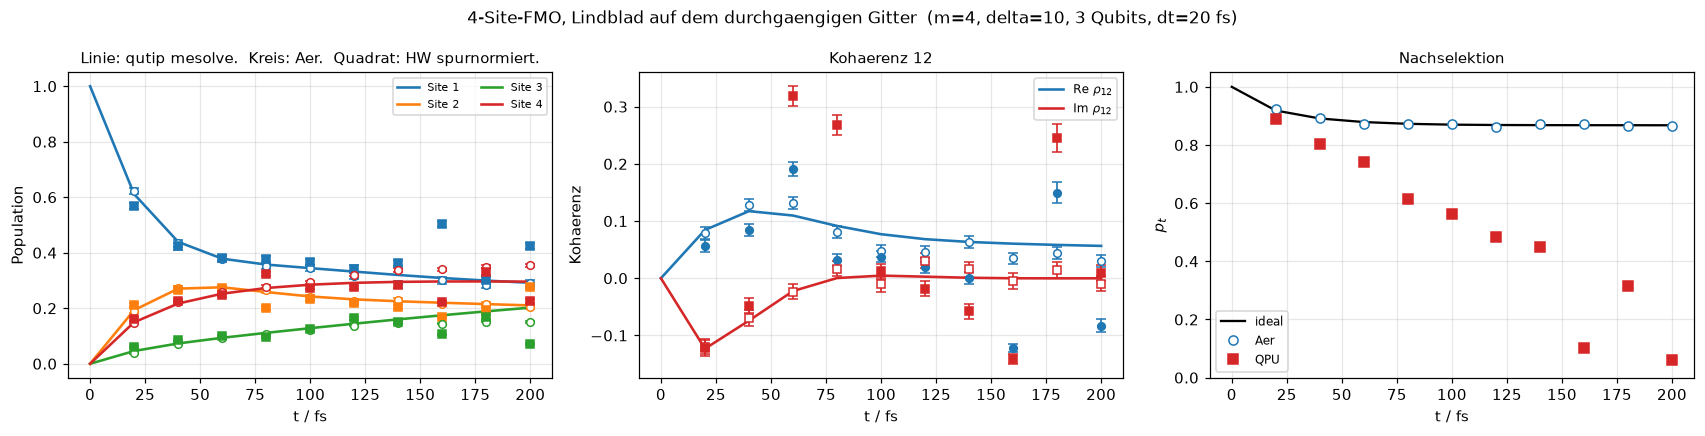

In [40]:
if counts is not None:
    rho_hw, err_hw, info_hw = hw.analyze(grid, jobs, counts, pairs=PAIRS)
    hw_tr = info_hw['rho_tr']      # SPURNORMIERT -- braucht p_t nicht
else:
    rho_hw = err_hw = info_hw = hw_tr = None
    print("  !! KEINE Hardwaredaten -- es wird NUR Aer geplottet.")

ts     = info_aer['t_index']
ref    = info_aer['reference']
t_pt   = ts * grid['dt_fs']
ok_a   = np.isfinite(np.real(rho_aer[:, 0, 0]))
ok_h   = np.isfinite(np.real(rho_hw[:, 0, 0])) if rho_hw is not None else None
aer_tr = info_aer['rho_tr']

n_ax = 2 + (rho_hw is not None)
fig, ax = plt.subplots(1, n_ax, figsize=(5.2 * n_ax, 4))

# (a) Populationen
for j in range(N):
    ax[0].plot(t_ex, np.real(ref[:, j, j]), color=cols[j], lw=1.7,
               label=f'Site {j+1}')
    ax[0].errorbar(t_pt[ok_a], np.real(aer_tr[ok_a, j, j]),
                   yerr=err_aer[ok_a, j, j], fmt='o', ms=5, capsize=3,
                   color=cols[j], mfc='white', lw=1.1)
    if rho_hw is not None:
        ax[0].errorbar(t_pt[ok_h], np.real(hw_tr[ok_h, j, j]),
                       yerr=err_hw[ok_h, j, j], fmt='s', ms=5, capsize=3,
                       color=cols[j], lw=1.1)
ax[0].set_xlabel('t / fs'); ax[0].set_ylabel('Population')
ax[0].set_title('Linie: qutip mesolve.  Kreis: Aer.'
                + ('  Quadrat: HW spurnormiert.' if rho_hw is not None else ''))
ax[0].legend(ncol=2, fontsize=7)

# (b) Kohaerenz, ebenfalls spurnormiert
a, b = PAIRS[0]
for part, lab, mk, cc, ee in ((np.real, r'$\mathrm{Re}$', 'o', 'C0', err_aer),
                              (np.imag, r'$\mathrm{Im}$', 's', 'C3',
                               info_aer['rho_err_im'])):
    ax[1].plot(t_ex, part(ref[:, a, b]), color=cc, lw=1.7,
               label=rf'{lab} $\rho_{{{a+1}{b+1}}}$')
    ax[1].errorbar(t_pt[ok_a], part(aer_tr[ok_a, a, b]), yerr=ee[ok_a, a, b],
                   fmt=mk, ms=5, capsize=3, color=cc, mfc='white', lw=1.1)
    if rho_hw is not None:
        eh = err_hw if part is np.real else info_hw['rho_err_im']
        ax[1].errorbar(t_pt[ok_h], part(hw_tr[ok_h, a, b]), yerr=eh[ok_h, a, b],
                       fmt=mk, ms=5, capsize=3, color=cc, lw=1.1)
ax[1].set_xlabel('t / fs'); ax[1].set_ylabel('Kohaerenz')
ax[1].set_title(f'Kohaerenz {a+1}{b+1}')
ax[1].legend(fontsize=8)

# (c) Nachselektion -- nur wenn es Hardwaredaten gibt
if rho_hw is not None:
    ax[2].plot(t_ex, p_ideal, 'k-', lw=1.5, label='ideal')
    ax[2].plot(t_pt, info_aer['p_success'], 'o', mfc='white', color='C0',
               label='Aer')
    ax[2].plot(t_pt, info_hw['p_success'], 's', color='C3', label='QPU')
    ax[2].set_xlabel('t / fs'); ax[2].set_ylabel(r'$p_t$')
    ax[2].set_title('Nachselektion')
    ax[2].set_ylim(0, 1.05); ax[2].legend(fontsize=8)

fig.suptitle(f'4-Site-FMO, Lindblad auf dem durchgaengigen Gitter  '
             f'(m={grid["m"]}, delta={DELTA:g}, {grid["n_qubits"]} Qubits, '
             f'dt={DT_FS:g} fs)', fontsize=11)
fig.tight_layout()
fig.savefig(f'{PIC}/markov_hardware_m{grid["m"]}.png', dpi=200,
            bbox_inches='tight')
plt.show()

---

## Was du erwarten kannst

Bei $t=10$ sind es 170 Zweiqubit-Gatter; bei einem „layered"-Fehler von 2,66e-3 liegt
die reine **Gattertreue damit bei 0,64** (und 0,97 bei $t=1$). Dazu kommen Auslesefehler
auf 12 Qubits. Rechne bei kleinen $t$ mit einer brauchbaren Kurve und bei $t=10$ mit
sichtbarer Abweichung.

Das ist ein **Machbarkeitsbeleg**, kein physikalisches Ergebnis — was du misst, ist zum
größten Teil die Maschine. Anders als im nicht-markovschen Fall ist der algorithmische
Fehler hier aber *nicht* vernachlässigbar: 6,2e-2 bei $t=10$ aus der Krylov-Abschneidung
bei $m=4$. Beim Einordnen der Hardwaredaten musst du ihn mitrechnen; die Aer-Kurve
enthält ihn bereits, deshalb ist **Aer und nicht qutip die richtige Vergleichslinie**
für das Gerätrauschen.

**Wenn du mehr Genauigkeit willst**, in dieser Reihenfolge:

1. **Weniger Zeitschritte.** Bis $t=3$ ist $m=4$ exakt, und die Gattertreue liegt bei
   0,90. Ein Lauf über $t=1\dots5$ hat 69 CZ und Treue 0,83 bei 1,0e-2 Algorithmusfehler
   — das ist der Bereich, in dem das Verfahren wirklich sauber ist.
2. **$\delta$ nachziehen.** Für einen kürzeren Lauf verschiebt sich das Optimum, weil
   $\lambda_t$ und $p_t$ beide von $t$ abhängen. Die Tabelle in 1a neu rechnen.
3. **Mehr Shots** nur bis $t\approx6$ — darüber dominiert der Algorithmusfehler, und
   Shots helfen nicht mehr.
4. **$m=8$** erst, wenn die Hardware deutlich bessere Zweiqubit-Gatter hat. Bei 814 CZ
   und Treue 0,11 ist das heute verschenkt.

## Vergleich mit dem nicht-markovschen Lauf

Beide Läufe verwenden dieselben $\lambda$, $\gamma$, $T$, dasselbe $H$ und dieselbe
Schaltkreisform. Die Unterschiede:

| | nicht-markovsch (HEOM) | markovsch (Lindblad) |
|---|---|---|
| Generator | $720\times720$ (45 ADOs) | $16\times16$ |
| Kompression | 720 → 4 (Faktor 180) | 16 → 4 (Faktor 4) |
| $\lVert P\rVert_2$ | 32,39 | **1,0038** |
| Eichung nötig? | zwingend | fast nicht — sie wird für die Ablesung genutzt |
| $\delta$-Optimum | 10 | 10 |
| Qubits / CZ je Schritt | 3 / 13 | 3 / 13 |

Dass die Gitterkosten **identisch** sind, obwohl der eine Generator 45-mal größer ist,
ist der eigentliche Punkt der Krylov-Kompression: die nötige Dimension hängt an der Zahl
der Zeitschritte, nicht an der Größe des Modells.
